Для решения задачи в качестве вещественной переменной из дтасета из 1 промежуточной возьмем показатель средней температуры станка temp_avg. 

Целевая переменная Y: 
temp_avg (средняя температура станка - нетепичное повышение температура является показателем износа)

Объясняющие переменные (X): 
1. power_avg (потребляемая мощность — чем сильнее нагружен двигатель, тем выше нагрев).
2. rpm_avg (скорость вращения — физическое трение напрямую зависит от оборотов).
3. operation_count (интенсивность работы — количество операций за 6 часов).

In [ ]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

 

In [33]:
# загрузим данные, определим таргет и фичи

df = pd.read_csv("../v_machine_features_predictive.csv", parse_dates=['snapshot_time'])

target = 'temp_avg'
features = ['power_avg', 'rpm_avg', 'operation_count']

df_poly = df[[target] + features].dropna() # подготовим датафрейм и очистим от пропусков.


In [34]:
df_poly

,temp_avg,power_avg,rpm_avg,operation_count
4,65.900082,1.207881,2367.635832,1
5,67.074685,1.251723,2432.010846,1
6,67.074685,1.251723,2432.010846,1
7,67.074685,1.251723,2432.010846,1
8,67.074685,1.251723,2432.010846,1
...,...,...,...,...
366548,67.353157,1.248136,2403.311057,1
366549,67.353157,1.248136,2403.311057,1
366550,67.353157,1.248136,2403.311057,1
366551,68.894950,1.284586,2515.760677,0


In [35]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

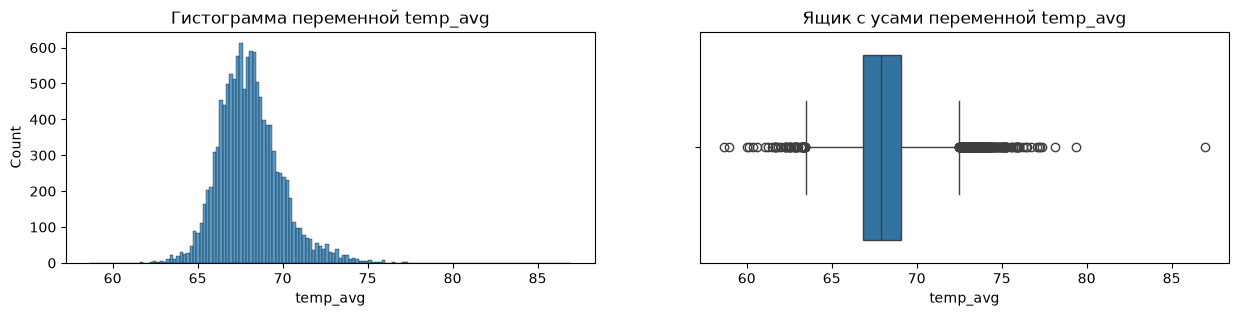

In [36]:
visualize_distribution(df_poly, variable = "temp_avg")

In [ ]:
# Убираем выбросы по правилу +/- 3 стандартных отклонения
df_poly = df_poly[np.abs((df_poly['temp_avg'] - df_poly['temp_avg'].mean()) / df_poly['temp_avg'].std()) <= 3]

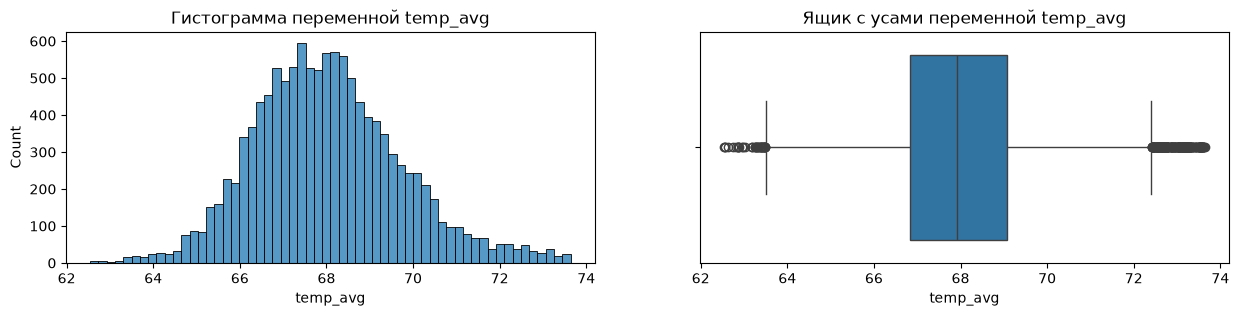

In [38]:
visualize_distribution(df_poly, variable = "temp_avg")

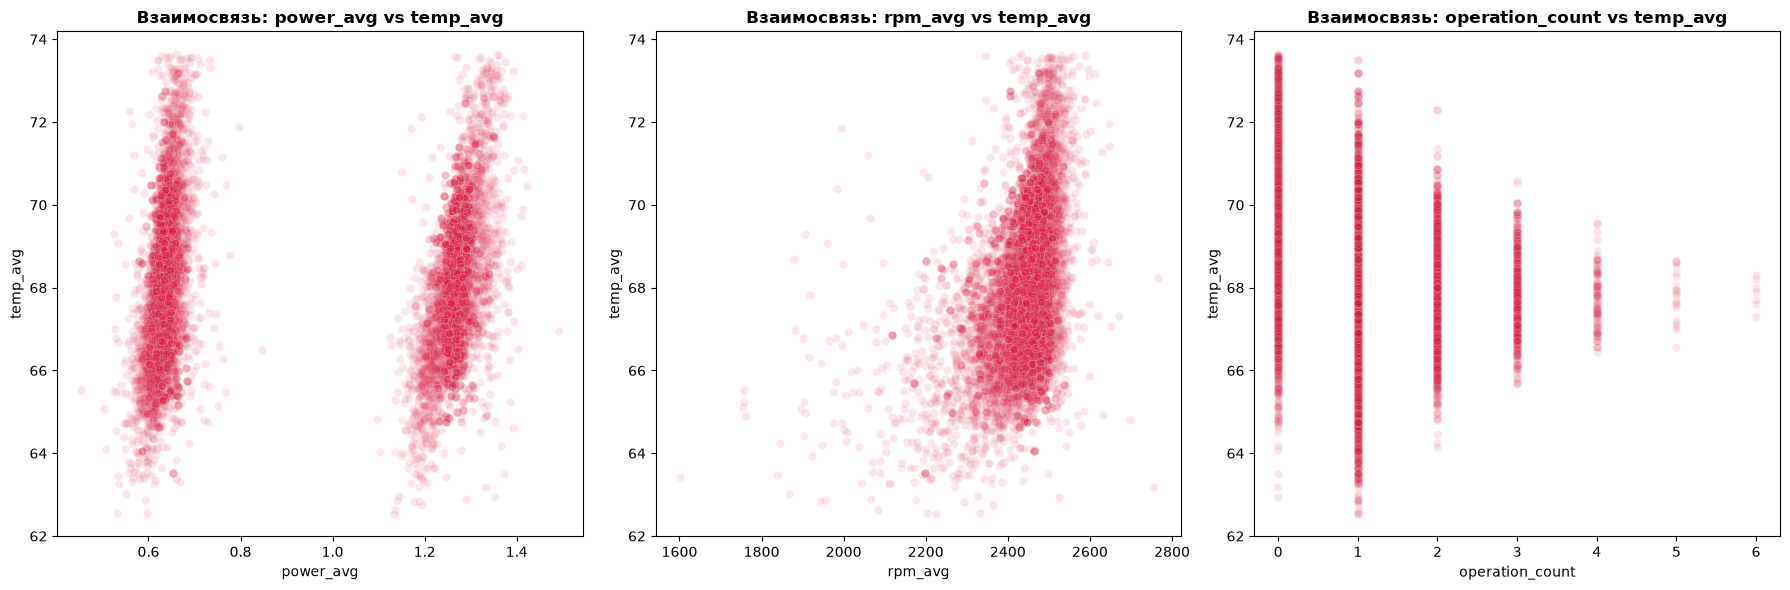

In [39]:
# построим тьочечечные диаграммы
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(features):
    sns.scatterplot(x=df_poly[col], y=df_poly[target], alpha=0.1, color='crimson', ax=axes[i])
    axes[i].set_title(f'Взаимосвязь: {col} vs {target}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

Проанализируем полученые графики.
1. Потребляемая мощность. power_avg vs temp_avg. На графике наблюдается двухкластерная прямая линейная зависимость. Данные разбились на 2 изолированные группы (первая в диапазоне 0.5 - 0.7, вторая 1.1 - 1.4). это указывает на то что есть 2 разные группы станков по мощности. Внутри каждой группы прослеживается линейная зависисмость (чем выше мощность, тем сильнее нагреваютеся узел станка)
2. Скорость вращения. rpm_avg vs temp_avg. На графике видно плотное облако точек с восходящим линейным трендом. Основная концентрация точек наблюдается в диапазоне от 2200 до 2600 оборотов. примерно с 2200 оборотов температура начинает рости с увеличением оборотов.
3. Интенсивность работы. operation_count vs temp_avg. На графике наблюдатеся максимальный разброс темературы на operation_count= 0 и 1. Возможно это может указывать на то, что станок может быть как горячим так и отсвшим после пересменки. по мере увеличения числа операций температура постепенно стабилизируется в райлне 68 градусов цельсия. Возрастающий тренд на графике отсутствует. Температура скорее стабилизируется с продолжительностью работы станков.

In [ ]:
# Разделим датасет на обучающую и тестовую выборки
X = df_poly[features]
y = df_poly[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 9641 строк
Размер тестовой выборки: 2411 строк


In [ ]:
# Выполним масштабирование объясняющих переменных

poly = PolynomialFeatures(degree=2, include_bias=False)

# Создаем полиномиальные фичи для train и test
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Проводим  масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print(f"Количество признаков после полиномиализации: {X_train_scaled.shape[1]}")
# Посмотрим на названия сгенерированных фичей
print("Сгенерированные нелинейные признаки:", poly.get_feature_names_out(features))



Количество признаков после полиномиализации: 9
Сгенерированные нелинейные признаки: ['power_avg' 'rpm_avg' 'operation_count' 'power_avg^2' 'power_avg rpm_avg'
 'power_avg operation_count' 'rpm_avg^2' 'rpm_avg operation_count'
 'operation_count^2']


In [ ]:
# Обучим модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающей выборке

# Функция для рассчета метрик кечества
def get_regression_metrics(y_true, y_pred):
    mean_y = np.mean(y_true)
    std_y = np.std(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Mean_Y': mean_y, 'Std_Y': std_y, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

poly_results = {}

# Спецификация 1: Ridge регрессия со слабым штрафом (alpha=0.1)
ridge_weak = Ridge(alpha=0.1)
ridge_weak.fit(X_train_scaled, y_train)
pred_rw = ridge_weak.predict(X_test_scaled) # Предсказание для слабой Ridge регрессии
poly_results['Ridge (alpha=0.1)'] = get_regression_metrics(y_test, pred_rw)

# Спецификация 2: Ridge регрессия с сильным штрафом (alpha=10.0)
ridge_strong = Ridge(alpha=10.0)
ridge_strong.fit(X_train_scaled, y_train)
pred_rs = ridge_strong.predict(X_test_scaled) # Предсказание для сильной Ridge регрессии
poly_results['Ridge (alpha=10.0)'] = get_regression_metrics(y_test, pred_rs)

# Спецификация 3: Lasso регрессия со слабым штрафом (alpha=0.001)
# (Для Lasso берем маленький alpha, чтобы она не занулила вообще все фичи сразу)
lasso_weak = Lasso(alpha=0.001, max_iter=10000, tol=0.005)
lasso_weak.fit(X_train_scaled, y_train)
pred_lw = lasso_weak.predict(X_test_scaled) # Предсказание для слабой Lasso регрессии
poly_results['Lasso (alpha=0.001)'] = get_regression_metrics(y_test, pred_lw)

# Спецификация 4: Lasso регрессия со средним штрафом (alpha=0.1)
lasso_strong = Lasso(alpha=0.1, max_iter=10000)
lasso_strong.fit(X_train_scaled, y_train)
pred_ls = lasso_strong.predict(X_test_scaled) # Предсказание для сильной Lasso регрессии
poly_results['Lasso (alpha=0.1)'] = get_regression_metrics(y_test, pred_ls)

# Сводный отчет в виде DataFrame
df_poly_metrics = pd.DataFrame(poly_results).T
display(df_poly_metrics)


,Mean_Y,Std_Y,MAE,MSE,RMSE,MAPE,R2
Ridge (alpha=0.1),68.018759,1.743173,1.211692,2.299715,1.516481,0.017778,0.243179
Ridge (alpha=10.0),68.018759,1.743173,1.213730,2.301291,1.517001,0.017809,0.242661
Lasso (alpha=0.001),68.018759,1.743173,1.212230,2.296568,1.515443,0.017786,0.244215
Lasso (alpha=0.1),68.018759,1.743173,1.232549,2.406179,1.551186,0.018077,0.208143


In [44]:
# Посмотрим, сколько фичей занулила слабая и сильная Lasso
print(f"Количество сохраненных признаков в Lasso (alpha=0.001): {np.sum(lasso_weak.coef_ != 0)} из {X_train_scaled.shape[1]}")
print(f"Количество сохраненных признаков в Lasso (alpha=0.1): {np.sum(lasso_strong.coef_ != 0)} из {X_train_scaled.shape[1]}")

# Посмотрим веса признаков для лучшей Lasso
print("\nКоэффициенты Lasso (alpha=0.001):")
for name, coef in zip(poly.get_feature_names_out(features), lasso_weak.coef_):
    print(f"{name}: {coef:.4f}")


Количество сохраненных признаков в Lasso (alpha=0.001): 8 из 9
Количество сохраненных признаков в Lasso (alpha=0.1): 2 из 9

Коэффициенты Lasso (alpha=0.001):
power_avg: -0.4971
rpm_avg: -1.7549
operation_count: -0.5889
power_avg^2: 0.5280
power_avg rpm_avg: -0.0000
power_avg operation_count: 0.0030
rpm_avg^2: 2.3514
rpm_avg operation_count: -0.1567
operation_count^2: 0.5491


Выберем спецификацию модели с наилучшим качеством

• Эффект регуляризации Lasso (alpha=0.1):
При жестком штрафе модель оставила всего 2 признака из 9, занулив остальные 7. Это подтверждает теоретическое свойство L1-регуляризации: при росте alpha она агрессивно отсекает фичи, оставляя только самые главные, что в данном случае привело к недообучению.
• Эффект регуляризации Lasso (alpha=0.001):
При оптимальном слабом штрафе модель сохранила 8 признаков из 9, сделав точечный выбор. Единственным полностью зануленным признаком (-0.0000) стало перекрестное произведение power_avg rpm_avg. Модель математически доказала, что совместное перемножение мощности и оборотов является избыточным (мультиколлинеарным) фактором, и полностью исключила его из расчетов, чтобы защитить систему от переобучения.

Выводы относительно полученной модели и ее качества:
С помощью масштабирования мы можем сравнивать коэффициенты всех 9 признаков между собой по абсолютной величине. 
Выявили, что чем больше коэффициент по модулю, тем сильнее признак влиентна температуру станка.

Интерпретация полученых весов:
1. наибольше влияние оказывает квадрат оборотов. rpm_avg^2: 2.3514. Он показывает что выделение тепла от трения растет пропорционально квадрату скорости вращения.
2. Эффект компенсации линейных и квадратичных признаков (rpm_avg, rpm_avg^2, power_avg, power_avg^2). пары rpm_avg (-1.7549) и rpm_avg^2 (+2.3514) и power_avg (-0.4971) и power_avg^2 (+0.5280).
    На малых и средних оборотах/мощностях температура станка удерживается на стабильном, даже слегка снижающемся уровне (за счет эффективной работы систем охлаждения и вентиляции). Но как только параметры проходят определенный критический порог, температура устремляется резко вверх.
3. Нелинейность производственного цикла (operation_count = -0.5889, operation_count^2 = +0.5491):
Эта пара коэффициентов также описывает нелинейный изгиб. Небольшое количество операций не успевает прогреть станок (влияет отрицательный коэффициент), но при переходе к интенсивной, непрерывной циклической работе (operation_count^2) включается фактор кумулятивного нагрева конструкции станка от непрерывного выполнения технологических задач.
4. Комбинированные эффекты (rpm_avg operation_count = -0.1567):
Отрицательный вес этого признака показывает синергию: если станок выполняет много операций на высоких оборотах, это характеризует режим легкой обработки деталей, при которой на единицу времени выделяется меньше тепла, чем при тяжелой работе.